# 04 - Modelado ARIMA, Prophet y LSTM

En este cuaderno se construyen los tres modelos de series de tiempo solicitados en el taller: ARIMA, Prophet y LSTM.

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA

pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", None)

import warnings
warnings.filterwarnings("ignore")

In [2]:
serie = pd.read_csv("../01_data/serie_externa_preparada.csv")
serie["Date"] = pd.to_datetime(serie["Date"])
serie = serie.sort_values("Date")

serie.head()

,Date,Sales,Promo,SchoolHoliday,StateHolidayFlag,Open,Promo2,CompetitionDistance
0,2013-01-01,97235,0.00,1,1,0.02,0.51,"5,409.74"
1,2013-01-02,6949829,0.00,1,0,1.00,0.51,"5,404.90"
2,2013-01-03,6347820,0.00,1,0,0.99,0.51,"5,404.90"
3,2013-01-04,6638954,0.00,1,0,0.99,0.51,"5,404.90"
4,2013-01-05,5951593,0.00,1,0,0.99,0.51,"5,404.90"


In [3]:
serie = serie.sort_values("Date")

serie.head()

,Date,Sales,Promo,SchoolHoliday,StateHolidayFlag,Open,Promo2,CompetitionDistance
0,2013-01-01,97235,0.00,1,1,0.02,0.51,"5,409.74"
1,2013-01-02,6949829,0.00,1,0,1.00,0.51,"5,404.90"
2,2013-01-03,6347820,0.00,1,0,0.99,0.51,"5,404.90"
3,2013-01-04,6638954,0.00,1,0,0.99,0.51,"5,404.90"
4,2013-01-05,5951593,0.00,1,0,0.99,0.51,"5,404.90"


In [4]:
fecha_corte = int(len(serie) * 0.8)

train_serie = serie.iloc[:fecha_corte]
test_serie = serie.iloc[fecha_corte:]

resumen_division = pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Prueba"],
    "Registros": [len(train_serie), len(test_serie)],
    "Fecha inicial": [train_serie["Date"].min(), test_serie["Date"].min()],
    "Fecha final": [train_serie["Date"].max(), test_serie["Date"].max()]
})


resumen_division

,Conjunto,Registros,Fecha inicial,Fecha final
0,Entrenamiento,753,2013-01-01,2015-01-23
1,Prueba,189,2015-01-24,2015-07-31


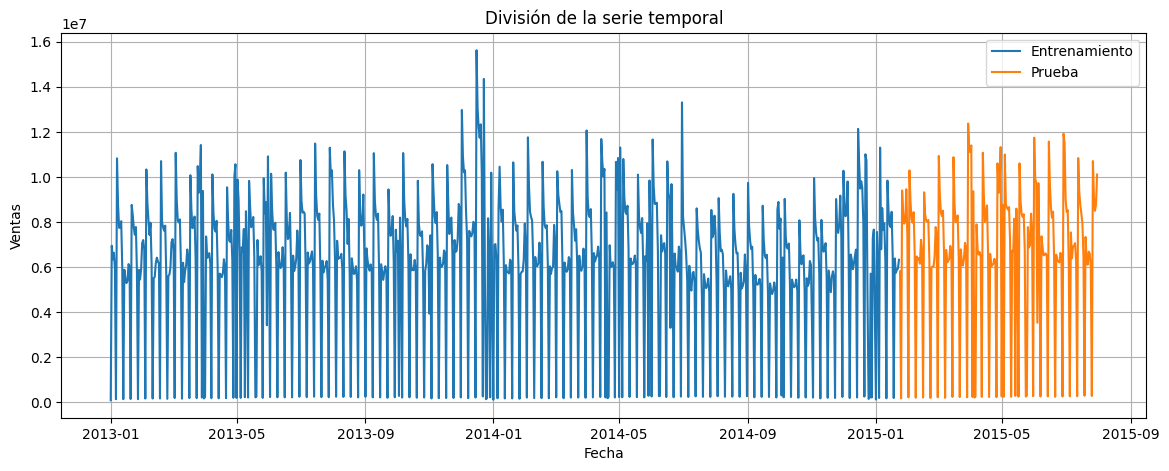

In [5]:
plt.figure(figsize=(14,5))
plt.plot(train_serie["Date"], train_serie["Sales"], label="Entrenamiento")
plt.plot(test_serie["Date"], test_serie["Sales"], label="Prueba")
plt.title("División de la serie temporal")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid(True)
plt.show()

## Modelo ARIMA

In [6]:
from statsmodels.tsa.arima.model import ARIMA

serie_arima = serie[["Date", "Sales"]].copy()
serie_arima = serie_arima.sort_values("Date")

train_arima = serie_arima.iloc[:fecha_corte].copy()
test_arima = serie_arima.iloc[fecha_corte:].copy()

historial = train_arima["Sales"].astype(float).copy()

modelo_arima = ARIMA(historial, order=(14, 1, 1))
resultado_arima = modelo_arima.fit()

predicciones_rolling = []
resultado_actual = resultado_arima

for valor_real in test_arima["Sales"].astype(float):
    prediccion = resultado_actual.forecast(steps=1)
    predicciones_rolling.append(float(prediccion.iloc[0]))
    resultado_actual = resultado_actual.append([valor_real], refit=False)

predicciones_arima = pd.DataFrame({
    "Date": test_arima["Date"].values,
    "Real": test_arima["Sales"].values,
    "Prediccion_ARIMA": predicciones_rolling
})

predicciones_arima["Date"] = pd.to_datetime(predicciones_arima["Date"])
predicciones_arima["Prediccion_ARIMA"] = predicciones_arima["Prediccion_ARIMA"].clip(lower=0)

predicciones_arima.head()

,Date,Real,Prediccion_ARIMA
0,2015-01-24,5811369,"5,775,527.24"
1,2015-01-25,179028,"695,344.67"
2,2015-01-26,9401803,"8,261,890.13"
3,2015-01-27,8392342,"7,913,481.10"
4,2015-01-28,7930037,"7,662,895.67"


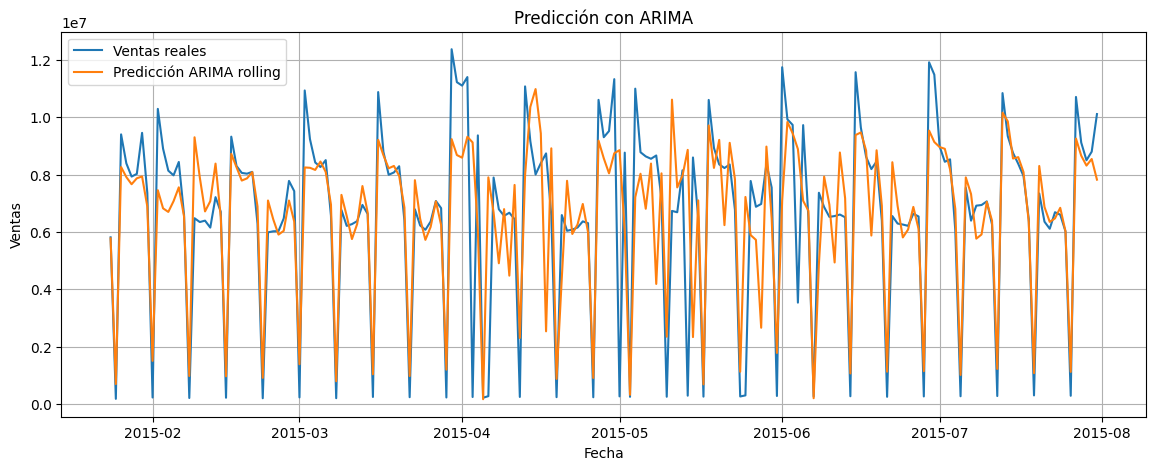

In [7]:
plt.figure(figsize=(14,5))
plt.plot(predicciones_arima["Date"], predicciones_arima["Real"], label="Ventas reales")
plt.plot(predicciones_arima["Date"], predicciones_arima["Prediccion_ARIMA"], label="Predicción ARIMA rolling")
plt.title("Predicción con ARIMA")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid(True)
plt.show()

## Modelo Prophet

In [8]:
from prophet import Prophet

In [9]:
prophet_data = serie.rename(columns={
    "Date": "ds",
    "Sales": "y"
})

train_prophet = prophet_data.iloc[:fecha_corte]
test_prophet = prophet_data.iloc[fecha_corte:]

train_prophet.head()

,ds,y,Promo,SchoolHoliday,StateHolidayFlag,Open,Promo2,CompetitionDistance
0,2013-01-01,97235,0.00,1,1,0.02,0.51,"5,409.74"
1,2013-01-02,6949829,0.00,1,0,1.00,0.51,"5,404.90"
2,2013-01-03,6347820,0.00,1,0,0.99,0.51,"5,404.90"
3,2013-01-04,6638954,0.00,1,0,0.99,0.51,"5,404.90"
4,2013-01-05,5951593,0.00,1,0,0.99,0.51,"5,404.90"


In [10]:
modelo_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode="multiplicative",
    changepoint_prior_scale=0.05
)

regresores = [
    "Promo",
    "SchoolHoliday",
    "StateHolidayFlag",
    "Open",
    "Promo2",
    "CompetitionDistance"
]

for reg in regresores:
    modelo_prophet.add_regressor(reg)

modelo_prophet.fit(train_prophet)

12:07:37 - cmdstanpy - INFO - Chain [1] start processing


12:07:37 - cmdstanpy - INFO - Chain [1] done processing


In [11]:
future = prophet_data[["ds"] + regresores]

forecast = modelo_prophet.predict(future)

pred_prophet = forecast[["ds", "yhat"]].iloc[fecha_corte:]

predicciones_prophet = pd.DataFrame({
    "Date": test_prophet["ds"].values,
    "Real": test_prophet["y"].values,
    "Prediccion_Prophet": pred_prophet["yhat"].values
})

predicciones_prophet["Prediccion_Prophet"] = predicciones_prophet["Prediccion_Prophet"].clip(lower=0)

predicciones_prophet.head()

,Date,Real,Prediccion_Prophet
0,2015-01-24,5811369,"6,001,543.23"
1,2015-01-25,179028,"92,172.82"
2,2015-01-26,9401803,"9,413,019.26"
3,2015-01-27,8392342,"8,282,638.15"
4,2015-01-28,7930037,"7,927,264.59"


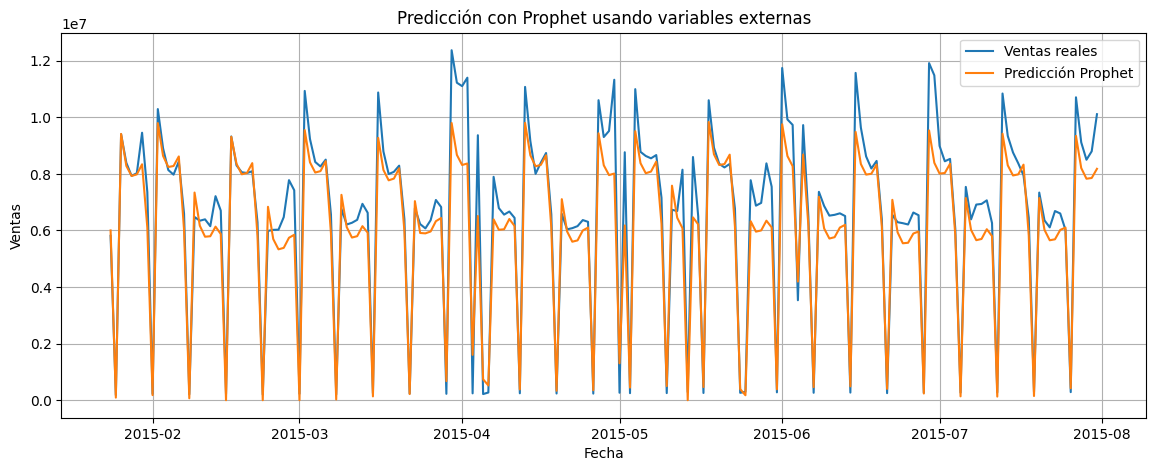

In [12]:
plt.figure(figsize=(14,5))
plt.plot(predicciones_prophet["Date"], predicciones_prophet["Real"], label="Ventas reales")
plt.plot(predicciones_prophet["Date"], predicciones_prophet["Prediccion_Prophet"], label="Predicción Prophet")
plt.title("Predicción con Prophet usando variables externas")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid(True)
plt.show()

## Modelo LSTM

In [13]:
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
tf.random.set_seed(42)


In [14]:
variables_lstm = [
    "Sales",
    "Promo",
    "SchoolHoliday",
    "StateHolidayFlag",
    "Open",
    "Promo2",
    "CompetitionDistance"
]

datos_lstm = serie[variables_lstm].values
datos_train_lstm = datos_lstm[:fecha_corte]

# El escalador se ajusta solo con entrenamiento para evitar data leakage.
scaler = MinMaxScaler()
scaler.fit(datos_train_lstm)
datos_escalados = scaler.transform(datos_lstm)


In [15]:
def crear_secuencias_multivariable(datos, fechas, pasos=30):
    X = []
    y = []
    fechas_y = []
    
    for i in range(pasos, len(datos)):
        X.append(datos[i-pasos:i, :])
        y.append(datos[i, 0])
        fechas_y.append(fechas.iloc[i])
        
    return np.array(X), np.array(y), pd.Series(fechas_y)

pasos = 30

X, y, fechas_y = crear_secuencias_multivariable(
    datos_escalados,
    serie["Date"],
    pasos
)


In [16]:
fecha_inicio_prueba = test_serie["Date"].min()

mascara_train = fechas_y < fecha_inicio_prueba
mascara_test = fechas_y >= fecha_inicio_prueba

X_train = X[mascara_train]
X_test = X[mascara_test]
y_train = y[mascara_train]
y_test = y[mascara_test]

fechas_test_lstm = fechas_y[mascara_test].reset_index(drop=True)

resumen_lstm = pd.DataFrame({
    "Conjunto": ["X_train", "X_test", "y_train", "y_test"],
    "Registros": [X_train.shape[0], X_test.shape[0], y_train.shape[0], y_test.shape[0]]
})

resumen_lstm

,Conjunto,Registros
0,X_train,723
1,X_test,189
2,y_train,723
3,y_test,189


In [17]:
modelo_lstm = Sequential()
modelo_lstm.add(LSTM(50, activation="tanh", input_shape=(pasos, X_train.shape[2])))
modelo_lstm.add(Dense(1))

modelo_lstm.compile(optimizer="adam", loss="mse")

In [18]:
historial_lstm = modelo_lstm.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=16,
    verbose=0
)


In [19]:
perdida_lstm = pd.DataFrame({
    "Modelo": ["LSTM"],
    "Pérdida final": [historial_lstm.history["loss"][-1]]
})

perdida_lstm

,Modelo,Pérdida final
0,LSTM,0.01


In [20]:
pred_lstm_escalado = modelo_lstm.predict(X_test, verbose=0)

pred_completo = np.zeros((len(pred_lstm_escalado), len(variables_lstm)))
real_completo = np.zeros((len(y_test), len(variables_lstm)))

pred_completo[:, 0] = pred_lstm_escalado.flatten()
real_completo[:, 0] = y_test

pred_lstm = scaler.inverse_transform(pred_completo)[:, 0]
real_lstm = scaler.inverse_transform(real_completo)[:, 0]


In [21]:
predicciones_lstm = pd.DataFrame({
    "Date": fechas_test_lstm,
    "Real": real_lstm,
    "Prediccion_LSTM": pred_lstm
})

predicciones_lstm["Prediccion_LSTM"] = predicciones_lstm["Prediccion_LSTM"].clip(lower=0)

predicciones_lstm.head()

,Date,Real,Prediccion_LSTM
0,2015-01-24,"5,811,369.00","5,162,536.63"
1,2015-01-25,"179,028.00","3,429,298.09"
2,2015-01-26,"9,401,803.00","10,624,170.12"
3,2015-01-27,"8,392,342.00","9,352,032.95"
4,2015-01-28,"7,930,037.00","8,672,557.04"


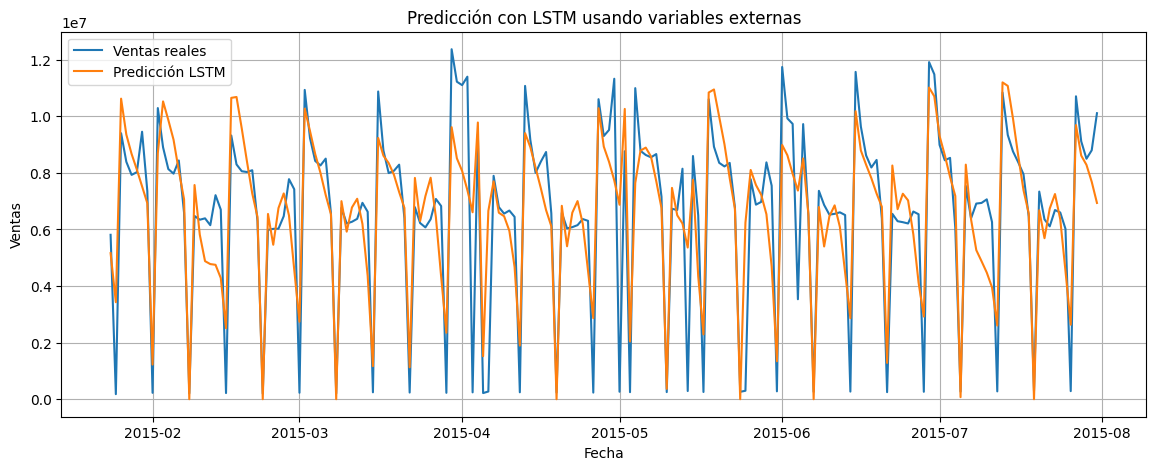

In [22]:
plt.figure(figsize=(14,5))
plt.plot(predicciones_lstm["Date"], predicciones_lstm["Real"], label="Ventas reales")
plt.plot(predicciones_lstm["Date"], predicciones_lstm["Prediccion_LSTM"], label="Predicción LSTM")
plt.title("Predicción con LSTM usando variables externas")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
predicciones_arima.to_csv("../01_data/predicciones_arima.csv", index=False)
predicciones_prophet.to_csv("../01_data/predicciones_prophet.csv", index=False)
predicciones_lstm.to_csv("../01_data/predicciones_lstm.csv", index=False)

## Conclusión

Se construyeron los tres modelos solicitados en el taller: ARIMA, Prophet y LSTM.

ARIMA se utilizó como modelo base de serie temporal sobre las ventas históricas. Prophet y LSTM se construyeron integrando variables externas disponibles en el Rossmann Store Sales Dataset, como promociones, festivos, apertura de tiendas, promoción extendida y distancia de competencia.

Cada modelo generó predicciones sobre el conjunto de prueba, las cuales serán evaluadas mediante RMSE, MAE y MAPE.